# Acoustic Drone Detection - Getting Started

This notebook provides an introduction to the acoustic drone detection pipeline.

**Istanbul Technical University - Telecommunication Engineering**

## Contents
1. Environment Setup
2. Data Loading and Exploration
3. Feature Extraction
4. Model Training
5. Evaluation

## 1. Environment Setup

In [3]:
##Do not need to run every time
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"])

0

In [2]:
# Check GPU availability
import torch
import warnings

#warnings.filterwarnings("ignore", category=UserWarning)     

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0.dev20260117+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070
CUDA version: 12.8


In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [5]:
# Add src to path
import sys
sys.path.append('..')

# Import project modules
from src.features.extractor import AudioFeatureExtractor, compute_blade_passing_frequency
from src.features.augmentation import AudioAugmentation, SpecAugment
from src.detection.models import create_model, count_parameters

## 2. Synthetic Drone Audio for Testing

Let's create a synthetic drone sound to test our pipeline.

In [6]:
def generate_synthetic_drone_audio(
    duration: float = 3.0,
    sample_rate: int = 16000,
    bpf: float = 136.7,
    num_harmonics: int = 5,
    noise_level: float = 0.1
):
    """Generate synthetic drone audio based on blade passing frequency."""
    t = np.linspace(0, duration, int(sample_rate * duration))
    
    audio = np.zeros_like(t)
    for i in range(1, num_harmonics + 1):
        amplitude = 1.0 / i
        audio += amplitude * np.sin(2 * np.pi * i * bpf * t)
    
    audio += noise_level * np.random.randn(len(t))
    audio = audio / np.max(np.abs(audio)) * 0.9
    
    return audio.astype(np.float32), sample_rate

drone_audio, sr = generate_synthetic_drone_audio(bpf=136.7)
print(f"Generated drone audio: {len(drone_audio)} samples, {len(drone_audio)/sr:.2f}s")

# Play
ipd.Audio(drone_audio, rate=sr)

Generated drone audio: 48000 samples, 3.00s


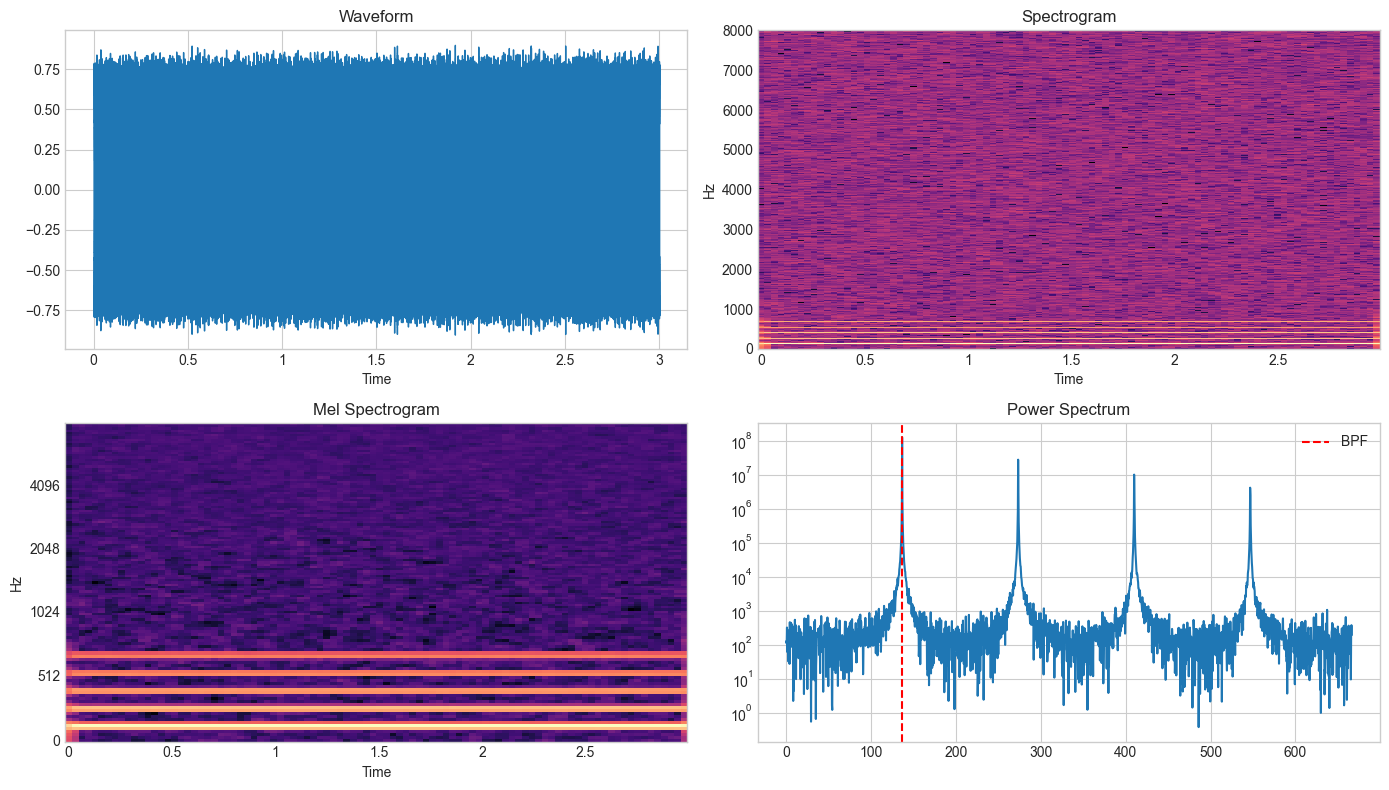

In [7]:
# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Waveform
ax = axes[0, 0]
librosa.display.waveshow(drone_audio, sr=sr, ax=ax)
ax.set_title('Waveform')

# Spectrogram
ax = axes[0, 1]
D = librosa.amplitude_to_db(np.abs(librosa.stft(drone_audio)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax)
ax.set_title('Spectrogram')

# Mel Spectrogram
ax = axes[1, 0]
mel_spec = librosa.feature.melspectrogram(y=drone_audio, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
ax.set_title('Mel Spectrogram')

# Power spectrum
ax = axes[1, 1]
fft = np.fft.rfft(drone_audio)
freqs = np.fft.rfftfreq(len(drone_audio), 1/sr)
power = np.abs(fft) ** 2
ax.semilogy(freqs[:2000], power[:2000])
ax.axvline(x=136.7, color='r', linestyle='--', label='BPF')
ax.set_title('Power Spectrum')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Feature Extraction

In [9]:
# Initialize feature extractor
extractor = AudioFeatureExtractor(sample_rate=16000, n_mels=128, n_mfcc=40)
print(f"Feature extractor initialized on {extractor.device}")

# Extract features
mel_spec = extractor.mel_spectrogram(drone_audio, normalize=True)
mfcc = extractor.mfcc(drone_audio, delta=True, delta_delta=True)
cnn_features = extractor.extract_for_cnn(drone_audio, target_length=128)

print(f"Mel spectrogram shape: {mel_spec.shape}")
print(f"MFCC (with deltas) shape: {mfcc.shape}")
print(f"CNN-ready features shape: {cnn_features.shape}")

Feature extractor initialized on cuda
Mel spectrogram shape: torch.Size([128, 94])
MFCC (with deltas) shape: torch.Size([120, 94])
CNN-ready features shape: torch.Size([1, 128, 128])


## 4. Model Testing

In [10]:
# Create and test models
for model_name in ['custom_cnn', 'crnn', 'efficientnet_b0']:
    model = create_model(model_name, num_classes=2)
    total, trainable = count_parameters(model)
    print(f"{model_name}: {total:,} params ({trainable:,} trainable)")

custom_cnn: 2,618,306 params (2,618,306 trainable)
crnn: 785,730 params (785,730 trainable)
efficientnet_b0: 4,335,422 params (4,335,422 trainable)


In [11]:
# Test forward pass
model = create_model('efficientnet_b0', num_classes=2, pretrained=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {torch.cuda.is_available()}")
model = model.to(device).eval()

batch = cnn_features.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(batch)
    probs = torch.softmax(output, dim=1)
    
print(f"Input: {batch.shape}")
print(f"Output: {output.shape}")
print(f"Probabilities: {probs.cpu().numpy()}")

Using device: True
Input: torch.Size([1, 1, 128, 128])
Output: torch.Size([1, 2])
Probabilities: [[0.4868094  0.51319057]]


## 5. BPF Analysis for Different Drones

In [12]:
drone_configs = [
    {'name': 'DJI Phantom 4', 'rpm': 4100, 'blades': 2},
    {'name': 'DJI Mavic 2', 'rpm': 5000, 'blades': 2},
    {'name': 'DJI Mini 3', 'rpm': 7000, 'blades': 2},
    {'name': 'Racing Quad (3-blade)', 'rpm': 25000, 'blades': 3},
]

print(f"{'Drone':<25} {'RPM':>8} {'Blades':>8} {'BPF (Hz)':>10}")
print("-" * 55)
for c in drone_configs:
    bpf = compute_blade_passing_frequency(c['rpm'], c['blades'])
    print(f"{c['name']:<25} {c['rpm']:>8} {c['blades']:>8} {bpf:>10.1f}")

Drone                          RPM   Blades   BPF (Hz)
-------------------------------------------------------
DJI Phantom 4                 4100        2      136.7
DJI Mavic 2                   5000        2      166.7
DJI Mini 3                    7000        2      233.3
Racing Quad (3-blade)        25000        3     1250.0


## Next Steps

1. Download real datasets using `scripts/download_datasets.py`
2. Train detection model with real data
3. Add classification for drone types

See `docs/ROADMAP.md` for the complete plan.